# Computations for Free Pendulum Motion Experiment

In [1]:
%load_ext autoreload
%autoreload

%matplotlib ipympl


In [2]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np

from scipy.integrate import odeint
from scipy.optimize import fmin


import os

Dataset Loading and Preprocessing

In [3]:
datasetPath = './dataRepo/volneKyv_mk2/'

Created files dictionary with considered data files and manualy set timestamps

In [4]:
files_dict = {
    'file3': {
        'filename': 'physicalMeasurement_2025_12_19_12_50_16.csv',
        'releasetime': 2.5449,
        'endtime': 11,
        }, 
    }

In this experiment, we manually deflect the arm of a laboratory pendulum device (AeroShield) to its limit in the direction of negative angle values and then release it. The resulting data is shown in the figure below.

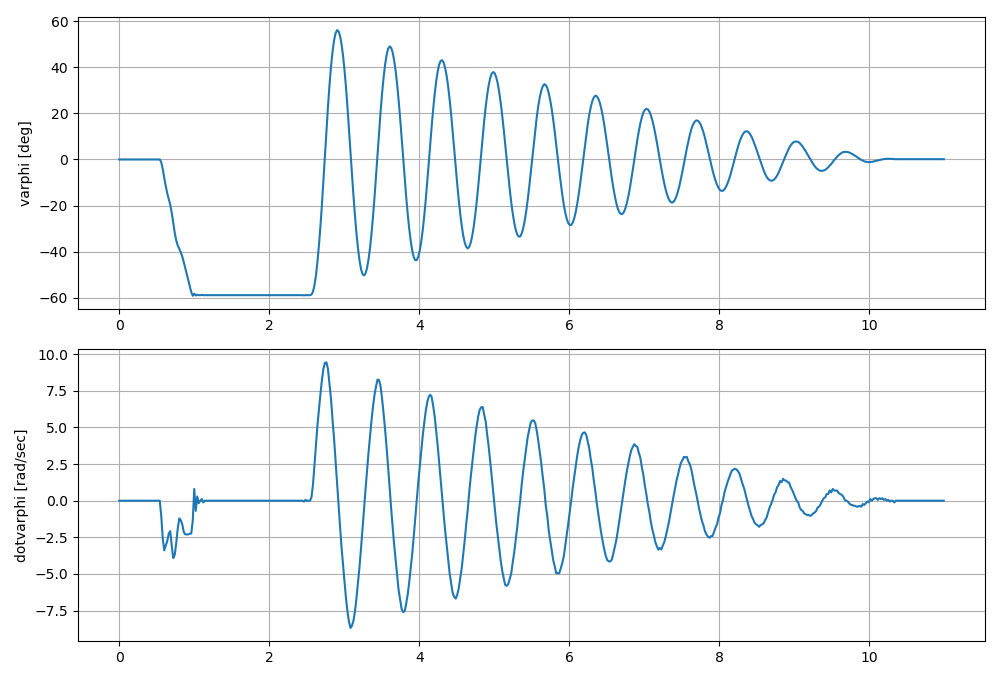

In [5]:
selectedFile = 'file3'

# ---------------------------------------
# run data job  to get work data
exec(open('./datajobs/dJob_volneKyv_01c.py', encoding='utf-8').read()) 
# ---------------------------------------

# ---------------------------------------
plt.figure(2, figsize=[10, 6.8])
plt.clf()
plt.subplot(2,1,1)
plt.ylabel('varphi [deg]')
plt.grid()
plt.plot(workdata_t, workdata_y, '-', label='workdata')

plt.subplot(2,1,2)
plt.ylabel('dotvarphi [rad/sec]')
plt.grid()
plt.plot(workdata_t, np.deg2rad(workdata_dy))

axes = plt.gcf().get_axes()
for ax in axes[1:]:
    ax.sharex(axes[0])
plt.tight_layout()
plt.show()
# ---------------------------------------

Create identdata (data for an identification procedure) from measured data

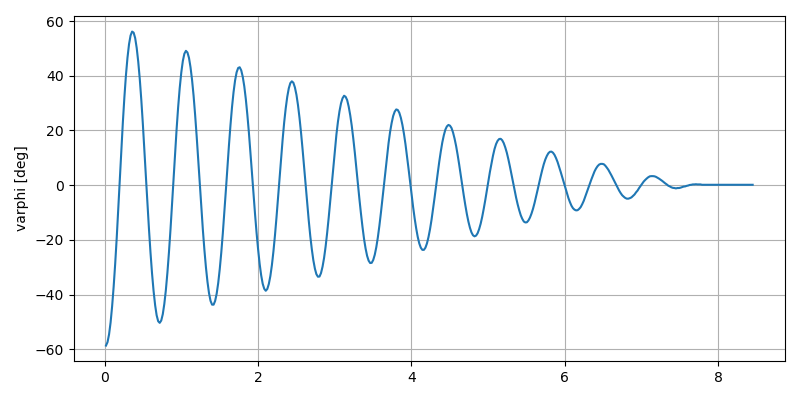

In [6]:
initVal_mask = (workdata_t >= files_dict[selectedFile]['releasetime'] - 0.1) & (workdata_t <= files_dict[selectedFile]['releasetime'])

initVal = np.mean(workdata_y[initVal_mask])

identData_mask = workdata_t >=  files_dict[selectedFile]['releasetime']

identData_t = workdata_t[identData_mask] - files_dict[selectedFile]['releasetime']
identData_y = workdata_y[identData_mask] 


# ---------------------------------------
plt.figure(3, figsize=[8, 4.0])
plt.clf()
plt.subplot(1,1,1)
plt.ylabel('varphi [deg]')
plt.grid()
plt.plot(identData_t, identData_y, '-', label='workdata')



axes = plt.gcf().get_axes()
for ax in axes[1:]:
    ax.sharex(axes[0])
plt.tight_layout()
plt.show()
# ---------------------------------------

In [7]:
# ---------------------------------------
# run requiered fcns def
exec(open('./fcn_dynModel/dynSysFyzKyv_suchvisk.py', encoding='utf-8').read()) 
# ---------------------------------------

In [8]:
# create fcns for ident procedure

def compMeasuredDataErrs(identData_t, identData_y, simdata_t, simdata_y):
    # find nearest indices in simdata_t for each workdata_t
    dt = simdata_t[1] - simdata_t[0]
    idx_float = (identData_t - simdata_t[0]) / dt
    idx_nearest = np.round(idx_float).astype(int)
    idx_nearest = np.clip(idx_nearest, 0, len(simdata_t) - 1)

    simdata_y_nearest = simdata_y[idx_nearest]

    errs = identData_y -(simdata_y_nearest)

    return errs


def fcn_Objective(p_x):

    if any(p_x < 0):
        fitFcn = 10**6
    else:

        p_x = np.array([L_T_kyv, m_kyv, p_x[0], p_x[1], p_x[2]])

        simdata_t = np.arange(0, identData_t[-1], 0.0025)                 

        odeOut = odeint(dynSysFyzKyv_suchvisk_v0,
            [np.deg2rad(initVal), 0],   
            simdata_t,
            args=(p_x,),
            )

        simdata_y = np.rad2deg(odeOut[:,0])

        errors_y = compMeasuredDataErrs(identData_t, identData_y, simdata_t, simdata_y)

        RMSE_err = np.sqrt(np.mean(errors_y**2)) 
 
        fitFcn = RMSE_err 

    return fitFcn


In [9]:
# initial parameter values for optimization
L_T_kyv = 0.073  # m
m_kyv = 0.01157  # kg
I_kyv = 0.00008  # kg.m2
Fc0_kyv = 0.0001  #
Fc1_kyv = 0.000025  # 

p_init = np.array([I_kyv, Fc0_kyv, Fc1_kyv])




fmin_results = fmin(fcn_Objective,
    p_init,
    maxiter=500,
    maxfun=500*4,
    disp=True,
    )

print(f"Parameters of the pendulum matching data from {selectedFile}:")
print(f"  L_T_kyv = {L_T_kyv:.8f} m")
print(f"  m_kyv   = {m_kyv:.8f} kg")
print(f"  I_kyv   = {fmin_results[0]:.8f} kg.m2")
print(f"  Fc0_kyv = {fmin_results[1]:.8f} Nm")
print(f"  Fc1_kyv = {fmin_results[2]:.8f} ")







p_x = np.array([L_T_kyv, m_kyv, fmin_results[0], fmin_results[1], fmin_results[2]])

simdata_t = np.arange(0, identData_t[-1], 0.0025)                 

odeOut = odeint(dynSysFyzKyv_suchvisk_v0,
    [np.deg2rad(initVal), 0],   
    simdata_t,
    args=(p_x,),
    )

simdata_y = np.rad2deg(odeOut[:,0])
simdata_dy = odeOut[:,1]

Optimization terminated successfully.
         Current function value: 1.394484
         Iterations: 69
         Function evaluations: 123
Parameters of the pendulum matching data from file3:
  L_T_kyv = 0.07300000 m
  m_kyv   = 0.01157000 kg
  I_kyv   = 0.00009367 kg.m2
  Fc0_kyv = 0.00014065 Nm
  Fc1_kyv = 0.00001051 


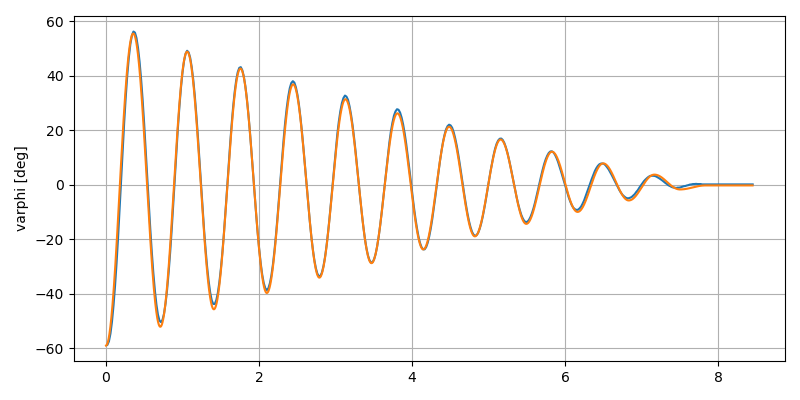

In [10]:
# plot comparison of ident data and sim data
# ---------------------------------------
plt.figure(4, figsize=[8, 4.0])
plt.clf()
plt.subplot(1,1,1)
plt.ylabel('varphi [deg]')
plt.grid()
plt.plot(identData_t, identData_y, '-', label='workdata')
plt.plot(simdata_t, simdata_y, '-', label='simdata')



axes = plt.gcf().get_axes()
for ax in axes[1:]:
    ax.sharex(axes[0])
plt.tight_layout()
plt.show()
# ---------------------------------------

# ---------------------------------------
# run fig job 
exec(open('./figjobs/figJob_02.py', encoding='utf-8').read()) 
# ---------------------------------------